Goal: Predict which illusion the subject is viewing based only on their hand movements.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
df_illusions = pd.read_csv("C:/CourseWork/Classifying_grip_strategies_ml/data/02_processed/visual_illusions_master_dataset.csv")

print("Visual Illusions Dataset loaded successfully")
print(f"Dateset shape: {df_illusions.shape}")

Visual Illusions Dataset loaded successfully
Dateset shape: (1608, 170)


In [3]:
df_illusions.head()

,subjName,trialN,visCond,illusion,targetPos,targetSize,FX,FY,FZ,FXVel,...,timeToXmax_thumb,timeToXmax_wrist,timeToYmax_index,timeToYmax_knuck,timeToYmax_thumb,timeToYmax_wrist,timeToZmax_index,timeToZmax_knuck,timeToZmax_thumb,timeToZmax_wrist
0,1,1,mono,Ponzo,cross,30,0.058377,0.058394,0.313187,-0.013500,...,0.375000,0.216666,0.308333,0.358333,0.316666,0.316666,0.750000,0.750000,0.750000,0.750000
1,1,2,mono,Ebbinghaus,square,40,-0.090791,0.056445,0.303091,-0.022930,...,0.108333,0.091667,0.433333,0.408333,0.383333,0.425000,1.091667,1.091667,1.091667,1.091667
2,1,3,mono,Ebbinghaus,cross,35,-0.060111,0.052680,0.301396,-0.026021,...,0.075000,0.050000,0.325000,0.325000,0.316667,0.366667,0.766667,0.766667,0.766667,0.766667
3,1,4,mono,Ponzo,square,35,0.065192,0.054594,0.291048,-0.012566,...,0.450000,0.475000,0.391667,0.416667,0.358334,0.400000,0.833334,0.833334,0.833334,0.833334
4,1,5,mono,Ponzo,square,35,-0.076105,0.053977,0.295869,-0.043558,...,0.150000,0.175000,0.466667,0.350000,0.341667,0.391667,0.891667,0.891667,0.891667,0.891667


In [4]:
# Feature Selection
identifier_cols = ['subjName', 'trialN']
condition_cols = ['visCond', 'illusion', 'targetPos', 'targetSize']

kinematic_features = df_illusions.select_dtypes(include=np.number).columns.tolist()
kinematic_features = [col for col in kinematic_features if col not in identifier_cols and col not in ['targetSize']]

print(f"\nIdentified {len(kinematic_features)} kinematic features.")

X_kinematic = df_illusions[kinematic_features].copy()

if X_kinematic.isnull().sum().sum() > 0:
    print("\nWarning: Missing values detected. Filling with the mean.")
    X_kinematic = X_kinematic.fillna(X_kinematic.mean())



Identified 164 kinematic features.


In [5]:
# Scaling
scalar = StandardScaler()
X_scaled = scalar.fit_transform(X_kinematic)
print("Kinematic Features have been scaled")

Kinematic Features have been scaled


# Phase 1: Unsupervised Learning

In [6]:
# PCA
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA reduced dimensions to {pca.n_components_} components, explaining {np.sum(pca.explained_variance_ratio_):.2f}% of variance.")

PCA reduced dimensions to 50 components, explaining 0.95% of variance.


# Find Optimal Number of Clusters (k) 


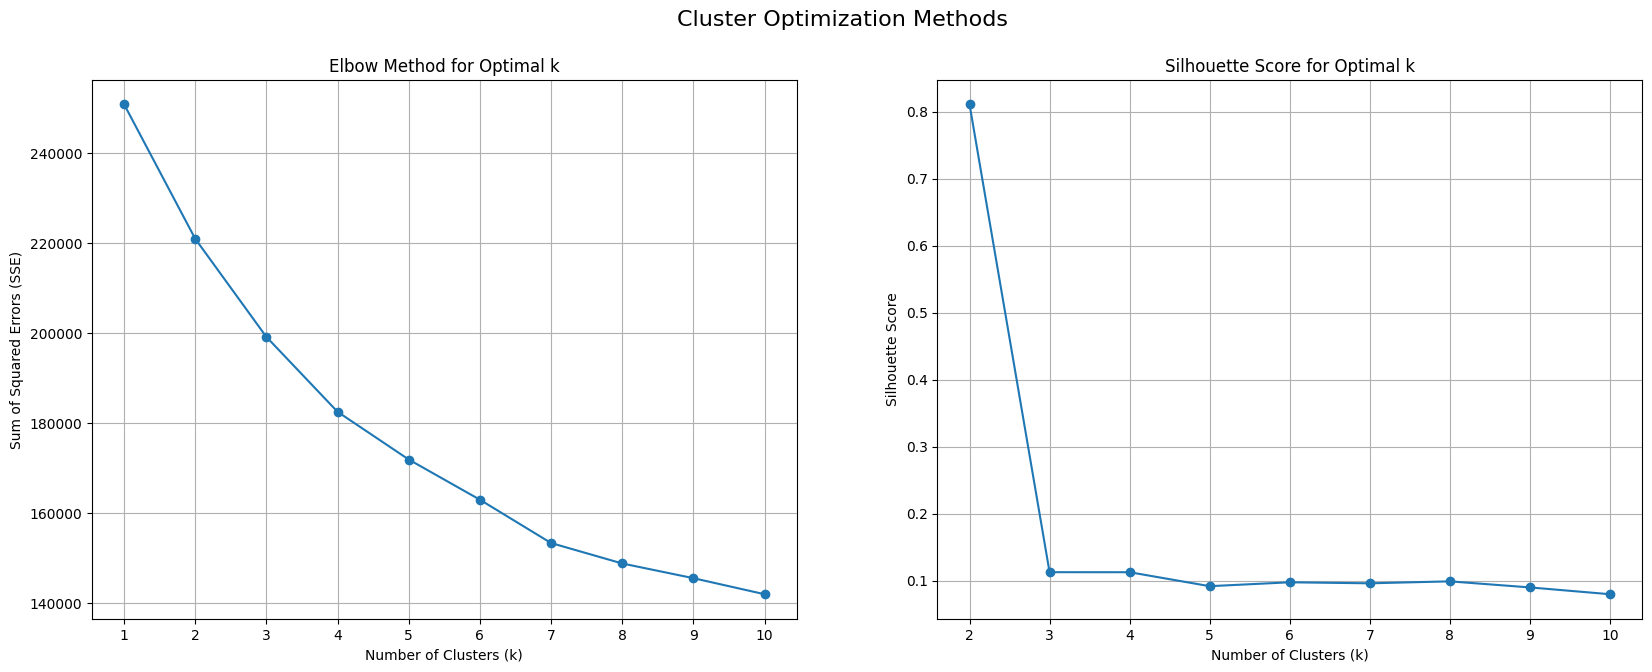

In [7]:
# Calculate SSE and Silhouette Scores
sse = []
silhouette_scores = []
# Silhouette score.
k_range_sil = range(2, 11)

for k in k_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    sse.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, kmeans.labels_))

## 1.2 Plot Elbow Method and Silhouette Score Side-by-Side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
plt.suptitle('Cluster Optimization Methods', fontsize=16)

# Elbow Method Plot
k_range_sse = range(1, 11)
# We need to calculate SSE for k=1 separately for the plot
sse_full = [KMeans(n_clusters=1, random_state=42, n_init=10).fit(X_pca).inertia_] + sse
ax1.plot(k_range_sse, sse_full, marker="o")
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Sum of Squared Errors (SSE)")
ax1.set_title("Elbow Method for Optimal k")
ax1.set_xticks(k_range_sse)
ax1.grid(True)

# Silhouette Score Plot
ax2.plot(k_range_sil, silhouette_scores, marker="o")
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score for Optimal k")
ax2.set_xticks(k_range_sil)
ax2.grid(True)

plt.show()


In [8]:
# --- Determine Optimal k ---
optimal_k_elbow = 4
optimal_k_sil = k_range_sil[np.argmax(silhouette_scores)]
print(f"Optimal k from Elbow Method: {optimal_k_elbow}")
print(f"Optimal k from Silhouette Score: {optimal_k_sil}")

print("\n" + "="*80 + "\n")


Optimal k from Elbow Method: 4
Optimal k from Silhouette Score: 2




#  Full Analysis for k from Elbow Method (k=4)

In [9]:
print(f"--- Analysis for k = {optimal_k_elbow} (from Elbow Method) ---\n")

# Clustering
kmeans_elbow = KMeans(n_clusters=optimal_k_elbow, random_state=42, n_init=10)
df_illusions['kmeans_strategy_elbow'] = kmeans_elbow.fit_predict(X_pca)

hierarchical_elbow = AgglomerativeClustering(n_clusters=optimal_k_elbow, linkage='ward')
df_illusions['hierarchical_strategy_elbow'] = hierarchical_elbow.fit_predict(X_pca)
print(f"Assigned trials to {optimal_k_elbow} strategies using K-Means and Hierarchical methods.")


--- Analysis for k = 4 (from Elbow Method) ---

Assigned trials to 4 strategies using K-Means and Hierarchical methods.


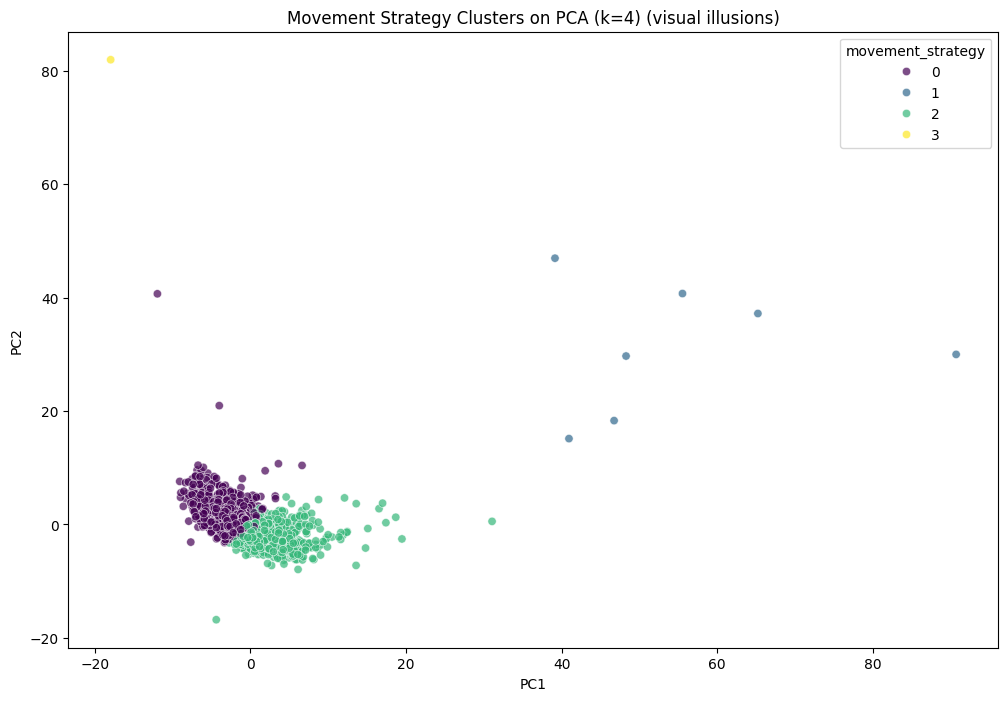

In [10]:
# Visualization
pca_df_elbow = pd.DataFrame(data=X_pca[:, :2], columns=['PC1', 'PC2'])
pca_df_elbow['movement_strategy'] = df_illusions['kmeans_strategy_elbow']

plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='movement_strategy', data=pca_df_elbow, palette='viridis', alpha=0.7)
plt.title(f'Movement Strategy Clusters on PCA (k={optimal_k_elbow}) (visual illusions)')
plt.show()


There are two massive clusters (purple and green) that are somewhat mixed, and then a handful of scattered points that have been forced into their own tiny clusters (blue and yellow). Clusters 1 and 3 are clearly just outlier points

Strategies 0 & 2: These two contain virtually all the data points (over 1600 trials combined) and are evenly split between the Ebbinghaus and Ponzo illusions.

Strategies 1 & 3: These are meaningless "anomaly" clusters, containing only 1 and 7 trials respectively.


In [11]:
# Interpretation and Comparison
print("\n--- Interpretation and Comparison (k=4) ---")
print("\nRelationship between K-Means strategies and 'illusion' type:")
print(pd.crosstab(df_illusions['kmeans_strategy_elbow'], df_illusions['illusion']))

print("\nCrosstab comparing K-Means vs. Hierarchical labels:")
print(pd.crosstab(df_illusions['kmeans_strategy_elbow'], df_illusions['hierarchical_strategy_elbow']))

ari_score_elbow = adjusted_rand_score(df_illusions['kmeans_strategy_elbow'], df_illusions['hierarchical_strategy_elbow'])
print(f"\nAdjusted Rand Index (ARI): {ari_score_elbow:.4f}")
if ari_score_elbow > 0.8:
    print("The high ARI score suggests a strong agreement between the two clustering methods.")
else:
    print("The ARI score suggests moderate to low agreement between the methods.")

print("\n" + "="*80 + "\n")



--- Interpretation and Comparison (k=4) ---

Relationship between K-Means strategies and 'illusion' type:
illusion               Ebbinghaus  Ponzo
kmeans_strategy_elbow                   
0                             363    398
1                               2      5
2                             443    396
3                               0      1

Crosstab comparing K-Means vs. Hierarchical labels:
hierarchical_strategy_elbow    0  1    2  3
kmeans_strategy_elbow                      
0                            640  0  121  0
1                              0  7    0  0
2                             78  0  761  0
3                              0  0    0  1

Adjusted Rand Index (ARI): 0.5684
The ARI score suggests moderate to low agreement between the methods.




ARI Score: 0.5666 (Moderate): It likely means that both K-Means and Hierarchical clustering agree on which points are the extreme outliers, but they disagree on how to split the two main, large clusters.

# Full Analysis for k from Silhouette Score 


In [12]:
print(f"--- Analysis for k = {optimal_k_sil} (from Silhouette Score) ---\n")

# Clustering
kmeans_sil = KMeans(n_clusters=optimal_k_sil, random_state=42, n_init=10)
df_illusions['kmeans_strategy_sil'] = kmeans_sil.fit_predict(X_pca)

hierarchical_sil = AgglomerativeClustering(n_clusters=optimal_k_sil, linkage='ward')
df_illusions['hierarchical_strategy_sil'] = hierarchical_sil.fit_predict(X_pca)
print(f"Assigned trials to {optimal_k_sil} strategies using K-Means and Hierarchical methods.")

--- Analysis for k = 2 (from Silhouette Score) ---

Assigned trials to 2 strategies using K-Means and Hierarchical methods.


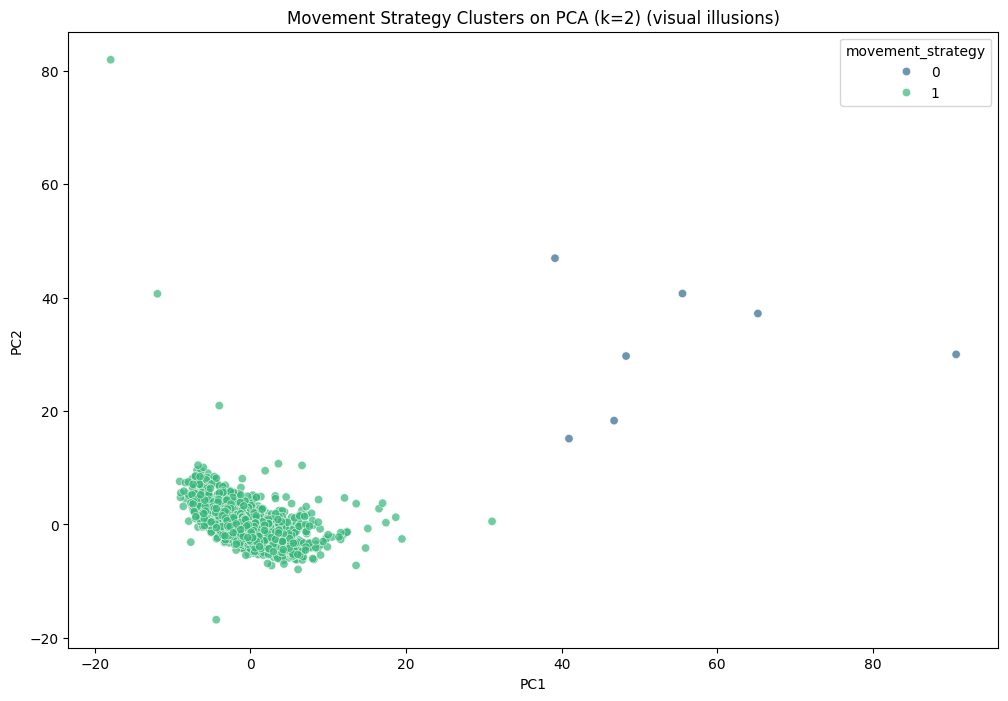

In [13]:
# Visualization
pca_df_sil = pd.DataFrame(data=X_pca[:, :2], columns=['PC1', 'PC2'])
pca_df_sil['movement_strategy'] = df_illusions['kmeans_strategy_sil']

plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='movement_strategy', data=pca_df_sil, palette='viridis', alpha=0.7)
plt.title(f'Movement Strategy Clusters on PCA (k={optimal_k_sil}) (visual illusions)')
plt.show()


Strategy 0 (The "Outlier/Anomalous Movement"): This cluster contains only 7 trials. These are the strange, non-standard movements that are kinematically very different from the rest.

Strategy 1 (The "Standard Grasping Movement"): This cluster contains 1601 trials—over 99% of the data. It is distributed almost perfectly evenly between the Ebbinghaus and Ponzo illusions.

In [14]:
# Interpretation and Comparison
print(f"\n--- Interpretation and Comparison (k={optimal_k_sil}) ---")
print("\nRelationship between K-Means strategies and 'illusion' type:")
print(pd.crosstab(df_illusions['kmeans_strategy_sil'], df_illusions['illusion']))

print("\nCrosstab comparing K-Means vs. Hierarchical labels:")
print(pd.crosstab(df_illusions['kmeans_strategy_sil'], df_illusions['hierarchical_strategy_sil']))

ari_score_sil = adjusted_rand_score(df_illusions['kmeans_strategy_sil'], df_illusions['hierarchical_strategy_sil'])
print(f"\nAdjusted Rand Index (ARI): {ari_score_sil:.4f}")
if ari_score_sil > 0.8:
    print("The high ARI score suggests a strong agreement between the two clustering methods.")
else:
    print("The ARI score suggests moderate to low agreement between the methods.")



--- Interpretation and Comparison (k=2) ---

Relationship between K-Means strategies and 'illusion' type:
illusion             Ebbinghaus  Ponzo
kmeans_strategy_sil                   
0                             2      5
1                           806    795

Crosstab comparing K-Means vs. Hierarchical labels:
hierarchical_strategy_sil     0  1
kmeans_strategy_sil               
0                             0  7
1                          1601  0

Adjusted Rand Index (ARI): 1.0000
The high ARI score suggests a strong agreement between the two clustering methods.


An ARI of 1.0 means that K-Means and Hierarchical Clustering agreed perfectly on how to partition the data into two groups. They both independently decided to group the vast majority of trials into one "standard movement" cluster and isolate the exact same 7 trials as "outliers."

# Supervised Learning (Predicting the 'illusion' type)

In [15]:
X_supervised = df_illusions[kinematic_features]
y_supervised = df_illusions['illusion']

le = LabelEncoder()
y_encoded = le.fit_transform(y_supervised)

groups = df_illusions['subjName']
group_kfold = GroupKFold(n_splits=5) 
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])

cv_scores = cross_val_score(pipeline, X_supervised, y_encoded, cv=group_kfold, groups=groups)

print(f"\nCross-validation accuracy scores for predicting illusion type: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")



Cross-validation accuracy scores for predicting illusion type: [0.7962963  0.7345679  0.75541796 0.77955272 0.66049383]
Mean CV Accuracy: 0.7453 (+/- 0.0473)


A Mean CV Accuracy of 74.53%.

While the unsupervised model couldn't find grossly different strategies, this supervised model shows that there are subtle but consistent kinematic differences between the movements. This means that even though the overall strategy is the same, the brain makes tiny, predictable adjustments to the movement based on the illusion it's perceiving. 

C:\Users\bharg\AppData\Local\Temp\ipykernel_35772\3818339366.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20), palette='rocket')


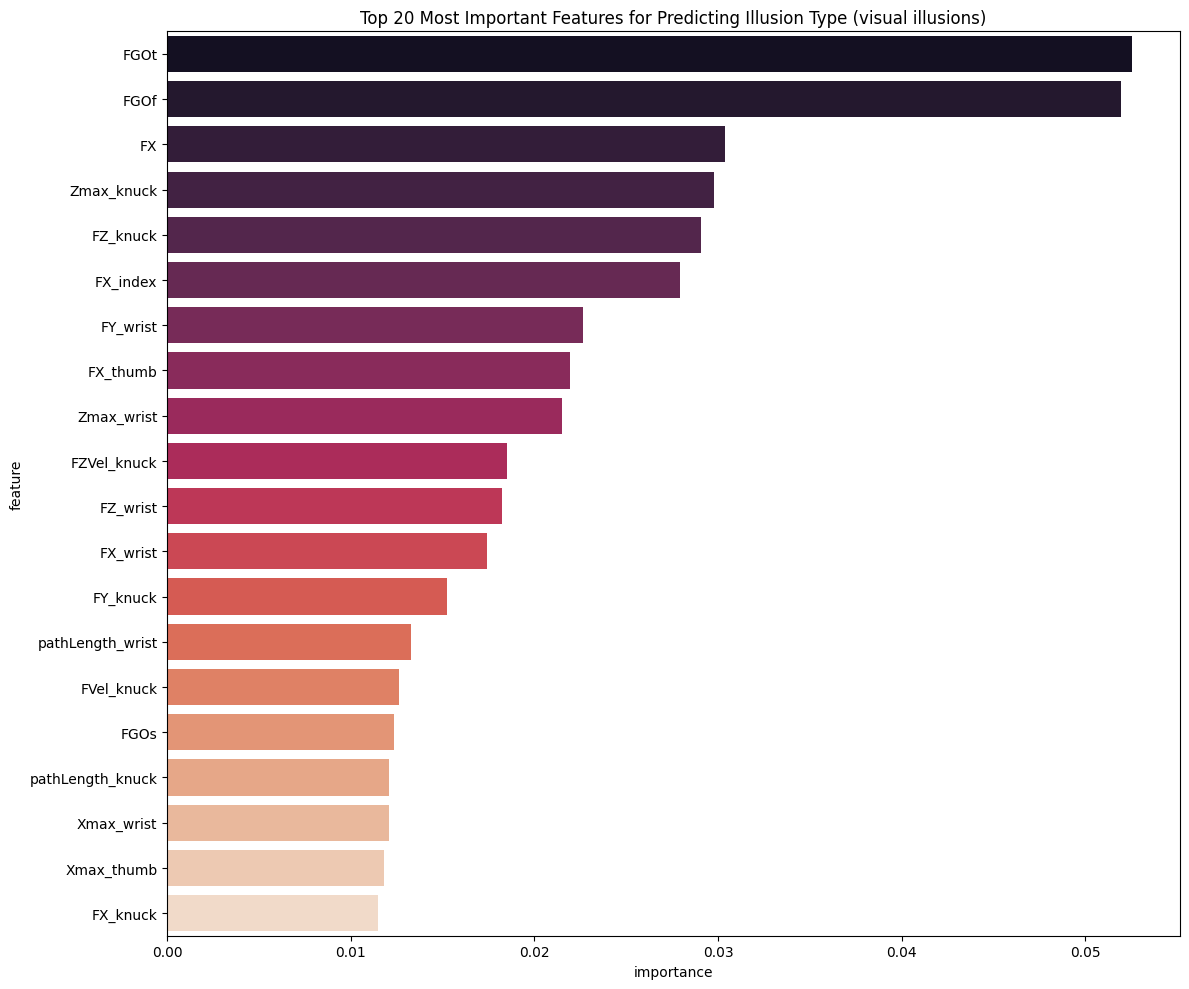

In [16]:
# Feature Importance
pipeline.fit(X_supervised, y_encoded)
importances = pipeline.named_steps['rf'].feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': kinematic_features,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20), palette='rocket')
plt.title('Top 20 Most Important Features for Predicting Illusion Type (visual illusions)')
plt.tight_layout()
plt.show()


Dominant Features: The top features are completely different from the distance-based tasks. Here, the winners are FGOt (Finger-Object Opening Time), FGOf (Finger-Object Final/Force), and FX (Final X position).

Interpretation: The model is telling us that the illusion's main effect isn't on the big "reaching" part of the movement. Instead, it's on the final, delicate, temporal aspects of the grasp itself.
FGOt (Time) being #1 suggests that the timing of when the fingers open relative to the object is the most critical variable affected by the illusion.

The importance of FX, FY, and other final position/force markers (FGOf, FGOs) shows that the illusion subtly alters the final configuration of the hand and fingers just before contact.

The illusion tricks the brain about the object's size, so the brain makes tiny miscalculations in the final moments of shaping the hand to grasp it.


Grasping vs. Aiming for Distance: We have demonstrated that for goal-directed tasks varying by distance, humans employ a small number of distinct, classifiable strategies (e.g., "Short-Range Point," "Long-Range Lunge"). Across both tasks, the primary kinematic correlate of intended distance is the maximum forward displacement (Z-axis) of the hand and fingers.

The Subtle Influence of Illusions: We have shown that visual illusions do not cause a wholesale change in motor strategy. However, they introduce subtle, systematic modulations to the kinematics. These changes are too small to be discovered as separate clusters but are strong enough to allow a machine learning model to predict which illusion a subject was viewing with ~75% accuracy.

A Tale of Two Motor Plans: The feature importance plots tell a compelling story.
To plan for distance, the brain primarily modulates the amplitude and power of the transport phase (the reach), evidenced by the importance of Zmax and FZVel.
To plan for grasping an illusory object, the brain makes adjustments to the timing and configuration of the grasp-shaping phase, evidenced by the importance of FGOt and final finger positions.